# Lab 5: Supervised Learning – Regression (ML + Deep Learning)

### Objectives
- Understand various machine learning and deep learning approaches for regression problems.
- Implement and compare traditional ML regression models with Artificial Neural Networks (ANN).
- Evaluate model performance using MAE, MSE, RMSE, and R².
- Analyze bias–variance tradeoff across ML and DL models.
- Understand how regression problems can be solved using both ML and DL paradigms.

### Exercise 1: Dataset Understanding and Preprocessing
1.	Load the dataset and display .head(), .info(), and .describe().
2.	Identify categorical and numerical features.
3.	Handle missing values if any.
4.	Encode categorical features using:
     - Label Encoding
     - One-Hot Encoding
5.	Normalize/standardize numerical features.
6.	Split the dataset into training and testing sets (80:20).


##### 1. Load the dataset and display .head(), .info(), and .describe().

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [8]:
import pandas as pd
from google.colab import files
import io

# 1. Upload the file from your local machine
uploaded = files.upload()

# 2. Read the uploaded CSV file into a pandas DataFrame
# The file name in the dictionary key 'your_filename.csv' must match the name of the file you uploaded
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  df = pd.read_csv(io.BytesIO(uploaded[fn]))
  # You can now work with the DataFrame 'df'
  print(df.head())


KeyboardInterrupt: 

In [ ]:
df = pd.read_csv("data.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Features:", numerical_features)

categorical_features = df.select_dtypes(include=['object']).columns
print("Categorical Features:", categorical_features)

Numerical Features: Index(['age', 'bmi', 'children', 'charges'], dtype='object')
Categorical Features: Index(['sex', 'smoker', 'region'], dtype='object')


In [ ]:
# Label encoding
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])

In [ ]:
# One-hot encoding
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [ ]:
scaler = StandardScaler()
X = df.drop("charges", axis=1)
y = df["charges"]

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
X[numerical_features] = scaler.fit_transform(X[numerical_features])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1070, 8)
Testing set size: (268, 8)


### Exercise 2: Apply Machine Learning Regression Models

#### Apply the following regression models to predict charges:
For each model:
- Train the model
- Predict on test data
- Evaluate and record:
     - MAE
     - MSE
     - RMSE
     - R² Score
- Create scatter plot of Actual vs Predicted values

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
def evaluation(y_test, y_pred, title):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f" {title} ")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)
    
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Charges")
    plt.ylabel("Predicted Charges")
    plt.title(f"{title} - Actual vs Predicted")
    plt.show()

#### • Simple Linear Regression (using bmi only)

 Simple Linear Regression (BMI) 
MAE : 9784.652596271331
MSE : 149085057.03839505
RMSE: 12210.039190698571
R2  : 0.03970193117941878


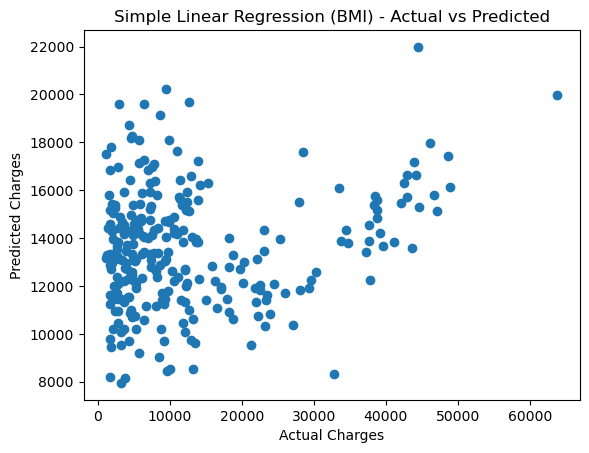

In [ ]:
X_bmi_train = X_train[['bmi']]
X_bmi_test = X_test[['bmi']]

slr = LinearRegression()
slr.fit(X_bmi_train, y_train)

y_pred_slr = slr.predict(X_bmi_test)

evaluation(y_test, y_pred_slr, "Simple Linear Regression (BMI)")

#### • Multiple Linear Regression (all features)

 Multiple Linear Regression 
MAE : 4181.19447375365
MSE : 33596915.85136147
RMSE: 5796.2846592762735
R2  : 0.7835929767120723


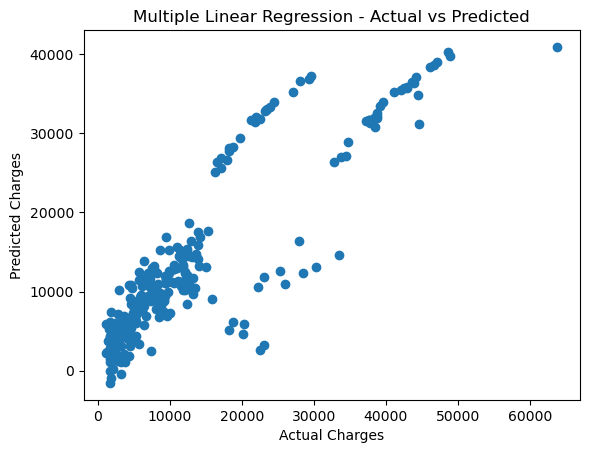

In [ ]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)

y_pred_mlr = mlr.predict(X_test)

evaluation(y_test, y_pred_mlr, "Multiple Linear Regression")

#### • Polynomial Regression (degree 2 and 3)

In [ ]:
poly = LinearRegression()

 Polynomial Regression (Degree 2) 
MAE : 2729.500133639437
MSE : 20712805.987918362
RMSE: 4551.132385233192
R2  : 0.8665830903164841


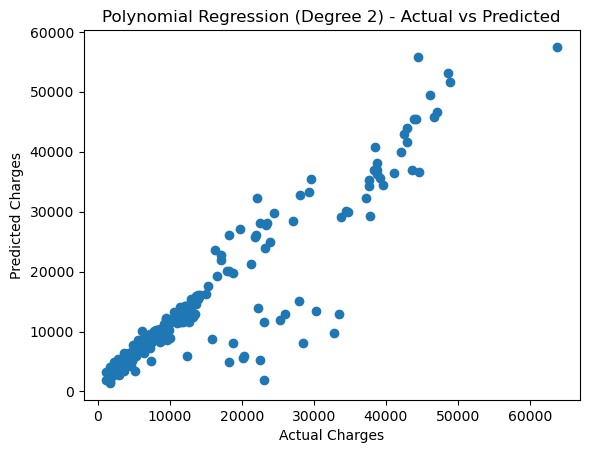

In [ ]:
# degree 2
poly2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

poly.fit(X_train_poly2, y_train)
y_pred_poly2 = poly.predict(X_test_poly2)

evaluation(y_test, y_pred_poly2, "Polynomial Regression (Degree 2)")

 Polynomial Regression (Degree 3) 
MAE : 2937.91859260038
MSE : 23498217.99893394
RMSE: 4847.496054555789
R2  : 0.8486414814914021


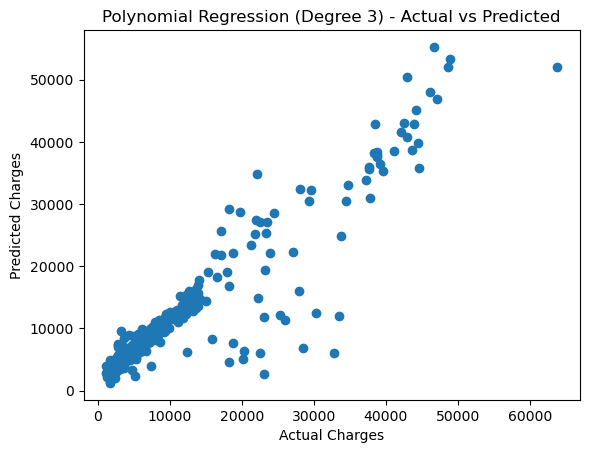

In [ ]:
# degree 3
poly3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

poly.fit(X_train_poly3, y_train)
y_pred_poly3 = poly.predict(X_test_poly3)

evaluation(y_test, y_pred_poly3, "Polynomial Regression (Degree 3)")

#### • Ridge Regression (with tuning alpha)

Best Alpha (Ridge): {'alpha': 10}
 Ridge Regression 
MAE : 4200.019136955063
MSE : 33709306.655907616
RMSE: 5805.971637539027
R2  : 0.7828690364681412


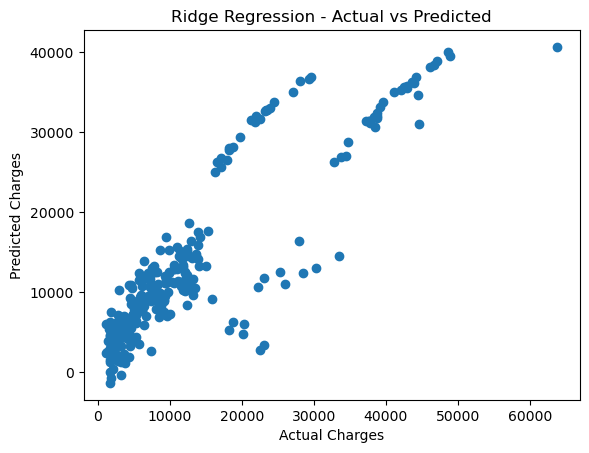

In [ ]:
ridge = Ridge()
params_ridge = {'alpha': [0.01, 0.1, 1, 10, 100]}

grid_ridge = GridSearchCV(ridge, params_ridge, cv=5)
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

print("Best Alpha (Ridge):", grid_ridge.best_params_)

evaluation(y_test, y_pred_ridge, "Ridge Regression")

#### • Lasso Regression (with tuning alpha)

Best Alpha (Lasso): {'alpha': 100}
 Lasso Regression 
MAE : 4214.680506401764
MSE : 34115895.267449126
RMSE: 5840.881377621799
R2  : 0.7802500868146746


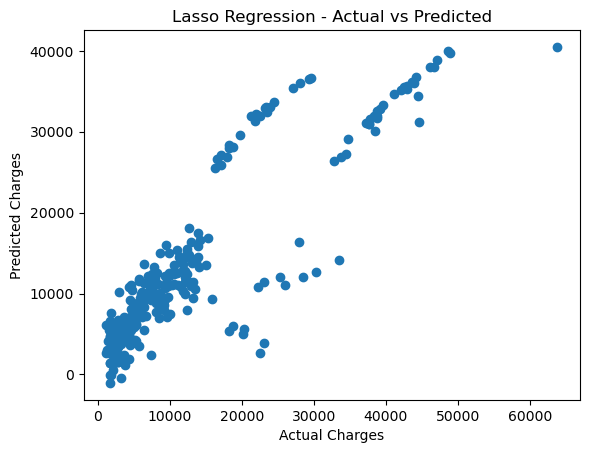

In [ ]:
lasso = Lasso(max_iter=10000)
params_lasso = {'alpha': [0.01, 0.1, 1, 10, 100]}

grid_lasso = GridSearchCV(lasso, params_lasso, cv=5)
grid_lasso.fit(X_train, y_train)

best_lasso = grid_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

print("Best Alpha (Lasso):", grid_lasso.best_params_)

evaluation(y_test, y_pred_lasso, "Lasso Regression")

#### • Decision Tree Regressor

 Decision Tree Regressor 
MAE : 3074.866285507463
MSE : 40153988.98731648
RMSE: 6336.717524658684
R2  : 0.7413570558581717


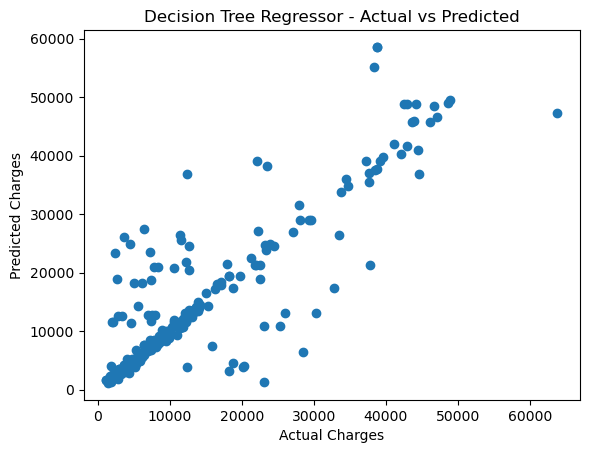

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

evaluation(y_test, y_pred_dt, "Decision Tree Regressor")

### Exercise 3: Artificial Neural Network (ANN) for Regression

#### Step 1: ANN Model Design

#### Design a Feed-Forward Neural Network for regression with:
- Input layer: number of neurons = number of features
- Hidden layer(s): 1 or 2 hidden layers
- Activation function:
	- Hidden layer: ReLU
	- Output layer: Linear activation
- Loss function: Mean Squared Error (MSE)
- Optimizer: Adam (default parameters)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
n_features = X_train.shape[1]

model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(n_features,)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer=Adam(), loss='mse')

NameError: name 'X_train' is not defined